In [35]:
from utils import read_im, save_im, normalize
import matplotlib.pyplot as plt
import numpy as np




def convolve_im(im, kernel):
    """ A function that convolves im with kernel

    Args:
        im ([type]): [np.array of shape [H, W, 3]]
        kernel ([type]): [np.array of shape [K, K]]
    Returns:
        [type]: [np.array of shape [H, W, 3]. should be same as im]
    """
    new_image = np.zeros_like(im, dtype=float)
    kernel_half_size = len(kernel)//2
    for c in range(3):
        # Convolving on each channel
        for i in range(len(im)):
            for j in range(len(im[i])):
                # Convolution so going from bottom to top and from right to left in the kernel
                for k in range(-kernel_half_size, kernel_half_size+1):
                    for l in range(-kernel_half_size, kernel_half_size+1):
                        try:
                            new_image[i, j, c] += kernel[k+kernel_half_size, l+kernel_half_size]*im[i+k, j+l, c]
                        except IndexError:
                            # Index out of bound: returning zero (to imitate a zero padding)
                            pass

    return new_image

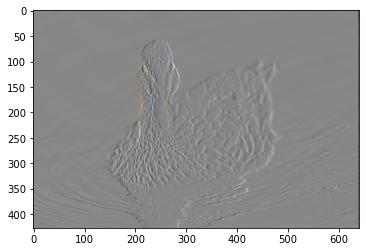

In [36]:
h_a = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

im = read_im("images/duck.jpeg")
im_sobel = convolve_im(im, h_a)
im_sobel = normalize(im_sobel)

plt.imshow(im_sobel)
save_im("results/duck_sobel.jpeg", im_sobel)

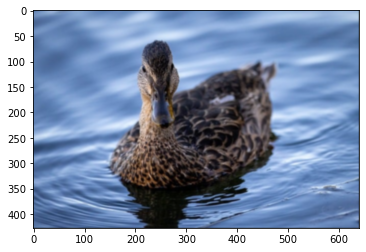

In [37]:
h_b = 1 / 256  * np.array([
        [1, 4, 6, 4, 1],
        [4, 16, 24, 16, 4],
        [6, 24, 36, 24, 6],
        [4, 16, 24, 16, 4],
        [1, 4, 6, 4, 1]
    ])
 
im_smoothed = convolve_im(im, h_b)
im_smoothed = normalize(im_smoothed)

plt.imshow(im_smoothed, cmap='gray')
save_im("results/duck_smoothed.jpeg", im_smoothed)